In [33]:
import baostock as bs
import pandas as pd
import datetime

# 1. 登录系统
lg = bs.login()
# 显示登陆返回信息
print('login respond error_code:' + lg.error_code)
print('login respond  error_msg:' + lg.error_msg)

# 2. 准备参数
# 股票代码：贵州茅台
stock_code = "sh.600519"

# 开始日期：严格遵守你的限制
start_date = '2019-01-02'

# 结束日期：获取当前日期，以最大化数据量，满足LightGBM对数据规模的需求
# 格式化为 YYYY-MM-DD
end_date = datetime.datetime.now().strftime('%Y-%m-%d')
print(f"Fetching data from {start_date} to {end_date}...")

# 3. 获取5分钟k线数据
# frequency="5" : 5分钟线
# adjustflag="2": 前复权(1) / 后复权(2) / 不复权(3)。
# 机器学习通常建议使用后复权或前复权，避免除权除息造成的股价断层干扰模型。原代码使用的是"2"(后复权)。
rs = bs.query_history_k_data_plus(
    stock_code,
    "date,time,open,high,low,close,volume,amount",
    start_date=start_date, 
    end_date=end_date,
    frequency="5", 
    adjustflag="2"
)

# 4. 打印结果集信息
print('query_history_k_data_plus respond error_code:' + rs.error_code)
print('query_history_k_data_plus respond  error_msg:' + rs.error_msg)

# 5. 解析数据
data_list = []
while (rs.error_code == '0') & rs.next():
    # 获取一条记录，将记录合并在一起
    data_list.append(rs.get_row_data())

# 转换为DataFrame
df = pd.DataFrame(data_list, columns=rs.fields)

# 6. 数据清洗与类型转换
# baostock返回的数据全是字符串类型，需要转换为数值类型
numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 处理时间索引
# baostock的time格式通常为 YYYYMMDDHHMMSSsss
df['time'] = pd.to_datetime(df['time'], format='%Y%m%d%H%M%S%f')
df = df.set_index('time').sort_index()

# 7. 登出系统
bs.logout()

# 8. 检查数据量
print(f"\n成功获取数据形状 (Shape): {df.shape}")
print(f"数据时间范围: 从 {df.index.min()} 到 {df.index.max()}")
print("前5行数据预览:")
print(df.head())

# 可选：保存到本地，避免重复下载
# df.to_csv('moutai_5min_data.csv')

login success!
login respond error_code:0
login respond  error_msg:success
Fetching data from 2019-01-02 to 2026-01-22...
query_history_k_data_plus respond error_code:0
query_history_k_data_plus respond  error_msg:success
logout success!

成功获取数据形状 (Shape): (82176, 7)
数据时间范围: 从 2019-01-02 09:35:00 到 2026-01-21 15:00:00
前5行数据预览:
                           date        open        high         low  \
time                                                                  
2019-01-02 09:35:00  2019-01-02  520.781405  522.506016  516.529640   
2019-01-02 09:40:00  2019-01-02  519.577592  520.798480  517.511473   
2019-01-02 09:45:00  2019-01-02  517.383408  518.237176  515.564882   
2019-01-02 09:50:00  2019-01-02  516.179595  516.529640  514.156165   
2019-01-02 09:55:00  2019-01-02  516.145444  516.529640  511.407032   

                          close   volume       amount  
time                                                   
2019-01-02 09:35:00  519.517828  1552766  945850400.0  
2019-

In [34]:
df

,date,open,high,low,close,volume,amount
time,,,,,,,
2019-01-02 09:35:00,2019-01-02,520.781405,522.506016,516.529640,519.517828,1552766,945850400.0
2019-01-02 09:40:00,2019-01-02,519.577592,520.798480,517.511473,517.554162,395656,240900640.0
2019-01-02 09:45:00,2019-01-02,517.383408,518.237176,515.564882,515.803937,332316,201314560.0
2019-01-02 09:50:00,2019-01-02,516.179595,516.529640,514.156165,516.145444,201370,121501600.0
2019-01-02 09:55:00,2019-01-02,516.145444,516.529640,511.407032,511.483871,361837,217579824.0
...,...,...,...,...,...,...,...
2026-01-21 14:40:00,2026-01-21,1353.870000,1354.030000,1352.050000,1352.050000,191000,258464335.0
2026-01-21 14:45:00,2026-01-21,1352.000000,1352.020000,1350.700000,1350.700000,308400,416734662.0
2026-01-21 14:50:00,2026-01-21,1350.720000,1351.760000,1350.020000,1350.040000,276600,373533041.0


In [36]:
#特征工程

import pandas as pd
import numpy as np

def calculate_technical_indicators(df):
    """
    计算常用的技术指标 (纯Pandas实现，无需TA-Lib)
    """
    df_ta = df.copy()
    
    # 1. 移动平均线 (MA)
    df_ta['ma_5'] = df_ta['close'].rolling(window=5).mean()
    df_ta['ma_10'] = df_ta['close'].rolling(window=10).mean()
    df_ta['ma_20'] = df_ta['close'].rolling(window=20).mean()
    df_ta['ma_60'] = df_ta['close'].rolling(window=60).mean()
    
    # 2. 相对强弱指数 (RSI) - 衡量超买超卖
    def calculate_rsi(data, window=14):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
        rs = gain / loss
        return 100 - (100 / (1 + rs))
    
    df_ta['rsi_6'] = calculate_rsi(df_ta['close'], window=6)
    df_ta['rsi_12'] = calculate_rsi(df_ta['close'], window=12)
    df_ta['rsi_24'] = calculate_rsi(df_ta['close'], window=24)

    # 3. MACD (异同移动平均线) - 捕捉趋势
    exp12 = df_ta['close'].ewm(span=12, adjust=False).mean()
    exp26 = df_ta['close'].ewm(span=26, adjust=False).mean()
    df_ta['macd'] = exp12 - exp26
    df_ta['macd_signal'] = df_ta['macd'].ewm(span=9, adjust=False).mean()
    df_ta['macd_hist'] = df_ta['macd'] - df_ta['macd_signal']

    # 4. 布林带 (Bollinger Bands) - 衡量相对价格高低和波动
    # 中轨通常是20日均线
    df_ta['bb_middle'] = df_ta['close'].rolling(window=20).mean()
    df_ta['bb_std'] = df_ta['close'].rolling(window=20).std()
    df_ta['bb_upper'] = df_ta['bb_middle'] + 2 * df_ta['bb_std']
    df_ta['bb_lower'] = df_ta['bb_middle'] - 2 * df_ta['bb_std']
    # 价格在布林带中的位置 (0表示下轨，1表示上轨)
    df_ta['bb_position'] = (df_ta['close'] - df_ta['bb_lower']) / (df_ta['bb_upper'] - df_ta['bb_lower'])

    # 5. ATR (平均真实波幅) - 衡量市场波动率 (重要！用于动态标签)
    high_low = df_ta['high'] - df_ta['low']
    high_close = np.abs(df_ta['high'] - df_ta['close'].shift())
    low_close = np.abs(df_ta['low'] - df_ta['close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    df_ta['atr_14'] = true_range.rolling(14).mean()
    
    # 6. 成交量特征
    # 量比：当前成交量 / 过去5周期均量
    df_ta['vol_ma5'] = df_ta['volume'].rolling(window=5).mean()
    df_ta['vol_ratio'] = df_ta['volume'] / df_ta['vol_ma5']
    # 成交量变化率
    df_ta['vol_change'] = df_ta['volume'].pct_change()

    return df_ta

def create_features(df):
    """
    构建用于模型训练的最终特征集
    """
    # 先计算基础指标
    df_feat = calculate_technical_indicators(df)
    
    # --- 基础收益率 ---
    df_feat['pct_chg'] = df_feat['close'].pct_change()
    
    # --- 滞后特征 (Lag Features) ---
    # 让模型看到过去的信息，LightGBM非常依赖这类特征
    lags = [1, 2, 3, 5, 10]
    for lag in lags:
        df_feat[f'pct_chg_lag_{lag}'] = df_feat['pct_chg'].shift(lag)
        df_feat[f'vol_ratio_lag_{lag}'] = df_feat['vol_ratio'].shift(lag)
        df_feat[f'rsi_6_lag_{lag}'] = df_feat['rsi_6'].shift(lag)
    
    # --- 时间特征 ---
    # 将时间转换为数值或分类特征
    df_feat['hour'] = df_feat.index.hour
    df_feat['minute'] = df_feat.index.minute
    df_feat['day_of_week'] = df_feat.index.dayofweek  # 周一=0, 周日=6
    
    # 周期性时间编码 (对于分钟数据很重要，例如9:30和15:00虽然数值远，但都是交易时段边缘)
    # 将一天的时间映射到 0-2pi 之间，然后取 sin/cos
    minutes_in_day = 24 * 60
    total_minutes = df_feat.index.hour * 60 + df_feat.index.minute
    df_feat['time_sin'] = np.sin(2 * np.pi * total_minutes / minutes_in_day)
    df_feat['time_cos'] = np.cos(2 * np.pi * total_minutes / minutes_in_day)

    return df_feat

def create_dynamic_labels(df, hold_period=2, threshold_multiplier=0.5):
    """
    使用动态阈值生成标签 (解决类别不平衡的核心)
    
    参数:
    hold_period: 持仓周期，预测未来第几根K线的收益 (默认2，即10分钟后)
    threshold_multiplier: 阈值系数。标签阈值 = ATR_14 * 系数
                          系数越大，标注为涨跌越难，中间震荡类越多。
    """
    df_labeled = df.copy()
    
    # 计算未来 N 根 K 线的累计收益率
    # shift(-hold_period) 将未来的价格拉到现在
    future_close = df_labeled['close'].shift(-hold_period)
    df_labeled['future_ret'] = (future_close - df_labeled['close']) / df_labeled['close']
    
    # 动态阈值：使用当前的 ATR (波动率) 作为基准
    # 注意：ATR是绝对值，需要转为相对比例，或者直接比较价格差
    # 这里我们用 ATR / Close 近似得到波动率百分比
    dynamic_threshold = (df_labeled['atr_14'] / df_labeled['close']) * threshold_multiplier
    
    # 确保阈值不过小 (设置一个极小值下限，比如 0.05%)
    dynamic_threshold = dynamic_threshold.clip(lower=0.0005)
    
    # 生成标签
    # 1: 涨 (未来收益 > 动态阈值)
    # 2: 跌 (未来收益 < -动态阈值) - LightGBM通常用 0,1,2 或 -1,0,1，这里用 0,1,2 方便处理
    # 0: 震荡
    
    def label_func(row):
        if pd.isna(row['future_ret']) or pd.isna(row['threshold']):
            return np.nan
        if row['future_ret'] > row['threshold']:
            return 2  # 涨
        elif row['future_ret'] < -row['threshold']:
            return 1  # 跌
        else:
            return 0  # 震荡

    # 临时列用于apply
    df_labeled['threshold'] = dynamic_threshold
    
    # 使用向量化操作替代 apply 以提升速度
    conditions = [
        (df_labeled['future_ret'] > df_labeled['threshold']),
        (df_labeled['future_ret'] < -df_labeled['threshold'])
    ]
    choices = [2, 1] # 2=Up, 1=Down, else=0
    df_labeled['label'] = np.select(conditions, choices, default=0)
    
    # 移除最后几行因为没有未来数据而无法计算标签的行
    # 以及前面因为计算MA/ATR产生NaN的行
    df_labeled = df_labeled.dropna()
    
    # 打印标签分布情况
    label_counts = df_labeled['label'].value_counts(normalize=True)
    print("\n标签分布情况 (动态阈值法):")
    print(label_counts)
    
    return df_labeled

# ==========================================
# 执行特征工程
# ==========================================
# 假设之前的 df 已经准备好
print("开始特征工程...")
df_features = create_features(df)

print("开始生成动态标签...")
# hold_period=2 表示预测10分钟后的涨跌
# threshold_multiplier=0.8 是一个经验值，根据波动率大小调整判定涨跌的标准
df_final = create_dynamic_labels(df_features, hold_period=2, threshold_multiplier=0.8)

# 最终检查
print(f"\n最终数据集形状: {df_final.shape}")
print("包含特征:", df_final.columns.tolist())

df_final

开始特征工程...
开始生成动态标签...

标签分布情况 (动态阈值法):
label
0    0.621468
1    0.189363
2    0.189168
Name: proportion, dtype: float64

最终数据集形状: (82112, 50)
包含特征: ['date', 'open', 'high', 'low', 'close', 'volume', 'amount', 'ma_5', 'ma_10', 'ma_20', 'ma_60', 'rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal', 'macd_hist', 'bb_middle', 'bb_std', 'bb_upper', 'bb_lower', 'bb_position', 'atr_14', 'vol_ma5', 'vol_ratio', 'vol_change', 'pct_chg', 'pct_chg_lag_1', 'vol_ratio_lag_1', 'rsi_6_lag_1', 'pct_chg_lag_2', 'vol_ratio_lag_2', 'rsi_6_lag_2', 'pct_chg_lag_3', 'vol_ratio_lag_3', 'rsi_6_lag_3', 'pct_chg_lag_5', 'vol_ratio_lag_5', 'rsi_6_lag_5', 'pct_chg_lag_10', 'vol_ratio_lag_10', 'rsi_6_lag_10', 'hour', 'minute', 'day_of_week', 'time_sin', 'time_cos', 'future_ret', 'threshold', 'label']


,date,open,high,low,close,volume,amount,ma_5,ma_10,ma_20,...,vol_ratio_lag_10,rsi_6_lag_10,hour,minute,day_of_week,time_sin,time_cos,future_ret,threshold,label
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 10:30:00,2019-01-03,507.052815,508.828653,506.625931,507.872432,74802,44447712.0,509.494592,509.144547,510.274936,...,0.662524,31.941309,10,30,3,0.382683,-0.923880,0.000219,0.003692,0
2019-01-03 10:35:00,2019-01-03,507.872432,509.170160,507.872432,508.000498,39788,23705840.0,508.886709,509.315300,510.069604,...,1.021792,24.333620,10,35,3,0.362438,-0.932008,0.001664,0.003720,0
2019-01-03 10:40:00,2019-01-03,508.000498,508.273703,507.232106,507.983422,32100,19082064.0,508.236138,509.485200,509.871957,...,1.178865,26.572770,10,40,3,0.342020,-0.939693,0.001361,0.003826,0
2019-01-03 10:45:00,2019-01-03,507.983422,508.845728,507.983422,508.845728,28800,17149888.0,507.920243,509.368234,509.718706,...,0.564681,44.102931,10,45,3,0.321439,-0.946930,-0.002164,0.003566,0
2019-01-03 10:50:00,2019-01-03,508.820115,508.973793,508.666437,508.674974,28100,16744560.0,508.275411,509.297371,509.573565,...,0.891293,42.001361,10,50,3,0.300706,-0.953717,-0.003038,0.003133,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-21 14:30:00,2026-01-21,1356.000000,1356.000000,1352.130000,1354.470000,303700,411289602.0,1357.518000,1358.993000,1359.882500,...,1.023006,31.746032,14,30,2,-0.608761,-0.793353,-0.001787,0.000671,1
2026-01-21 14:35:00,2026-01-21,1354.480000,1354.520000,1353.000000,1354.000000,176301,238703739.0,1356.318000,1358.373000,1359.413000,...,1.104211,47.580645,14,35,2,-0.625923,-0.779884,-0.002437,0.000725,1
2026-01-21 14:40:00,2026-01-21,1353.870000,1354.030000,1352.050000,1352.050000,191000,258464335.0,1354.910000,1357.567000,1358.915500,...,0.700934,49.166667,14,40,2,-0.642788,-0.766044,-0.001487,0.000805,1


In [42]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. 数据准备
# ==========================================
# 假设 df_final 是上一步特征工程生成的最终数据框
# 移除包含 NaN 的行（如果有残留）
df_final = df_final.dropna()

# 修正点：将 'date' 加入到排除列表中
# 'code' 如果存在也需要排除
exclude_cols = [
    'label', 'threshold', 'future_ret', 
    'open', 'high', 'low', 'close', 'volume', 'amount', 'pct_chg',
    'date', 'code'  # <--- 这里加上 date 和 code
]

# 动态筛选特征列
feature_cols = [c for c in df_final.columns if c not in exclude_cols]

print(f"使用的特征数量: {len(feature_cols)}")
print(f"特征列表: {feature_cols}")

# 再次确认所有特征列都是数值类型
# 如果还有非数值列，这里会报错或打印出来
print("\n检查特征数据类型:")
print(df_final[feature_cols].dtypes)

X = df_final[feature_cols]
y = df_final['label']

# ==========================================
# 2. 划分训练集和验证集 (TimeSeries Split)
# ==========================================
# 必须按时间顺序切分，不能 shuffle
split_index = int(len(df_final) * 0.8)

X_train, X_val = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_val = y.iloc[:split_index], y.iloc[split_index:]

print(f"训练集大小: {len(X_train)}")
print(f"验证集大小: {len(X_val)}")
print("训练集时间范围:", df_final.index[:split_index].min(), "至", df_final.index[:split_index].max())
print("验证集时间范围:", df_final.index[split_index:].min(), "至", df_final.index[split_index:].max())

# ==========================================
# 3. LightGBM 模型参数设置
# ==========================================
# 这里的参数是针对金融噪音频繁的特点优化的
params = {
    'objective': 'multiclass',      # 多分类问题 (0:震荡, 1:跌, 2:涨)
    'num_class': 3,                 # 类别数量
    'metric': 'multi_logloss',      # 评估指标
    'boosting_type': 'gbdt',        # 梯度提升决策树
    
    # --- 核心抗过拟合参数 ---
    'learning_rate': 0.05,          # 学习率，较小的值通常泛化更好
    'n_estimators': 1000,           # 最大树数量 (配合 early_stopping 使用)
    'num_leaves': 31,               # 叶子节点数，控制模型复杂度
    'max_depth': 6,                 # 树的最大深度，防止过深过拟合
    'min_child_samples': 20,        # 叶子节点最小样本数
    
    # --- 类别不平衡处理 (关键) ---
    'class_weight': 'balanced',     # 自动根据样本数量调整权重，解决“只猜震荡”的问题
    
    # --- 正则化与抽样 ---
    'subsample': 0.8,               # 行采样 (Bagging)，防止过拟合
    'colsample_bytree': 0.8,        # 列采样 (Feature Fraction)
    'reg_alpha': 0.1,               # L1 正则化
    'reg_lambda': 0.1,              # L2 正则化
    
    'random_state': 42,
    'n_jobs': -1,                   # 使用所有 CPU 核心
    'verbose': -1                   # 减少日志输出
}

# ==========================================
# 4. 模型训练
# ==========================================
print("\n开始训练 LightGBM 模型...")

model = lgb.LGBMClassifier(**params)

# 训练时使用 early_stopping
# 如果验证集上的 multi_logloss 在 50 轮内没有下降，则停止训练
callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=100)
]

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['Train', 'Valid'],
    eval_metric='multi_logloss',
    callbacks=callbacks
)



使用的特征数量: 39
特征列表: ['ma_5', 'ma_10', 'ma_20', 'ma_60', 'rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal', 'macd_hist', 'bb_middle', 'bb_std', 'bb_upper', 'bb_lower', 'bb_position', 'atr_14', 'vol_ma5', 'vol_ratio', 'vol_change', 'pct_chg_lag_1', 'vol_ratio_lag_1', 'rsi_6_lag_1', 'pct_chg_lag_2', 'vol_ratio_lag_2', 'rsi_6_lag_2', 'pct_chg_lag_3', 'vol_ratio_lag_3', 'rsi_6_lag_3', 'pct_chg_lag_5', 'vol_ratio_lag_5', 'rsi_6_lag_5', 'pct_chg_lag_10', 'vol_ratio_lag_10', 'rsi_6_lag_10', 'hour', 'minute', 'day_of_week', 'time_sin', 'time_cos']

检查特征数据类型:
ma_5                float64
ma_10               float64
ma_20               float64
ma_60               float64
rsi_6               float64
rsi_12              float64
rsi_24              float64
macd                float64
macd_signal         float64
macd_hist           float64
bb_middle           float64
bb_std              float64
bb_upper            float64
bb_lower            float64
bb_position         float64
atr_14              float

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20



验证集评估报告
              precision    recall  f1-score   support

      震荡 (0)       0.74      0.62      0.67     10375
      下跌 (1)       0.25      0.27      0.26      3086
      上涨 (2)       0.23      0.33      0.27      2962

    accuracy                           0.50     16423
   macro avg       0.40      0.41      0.40     16423
weighted avg       0.55      0.50      0.52     16423



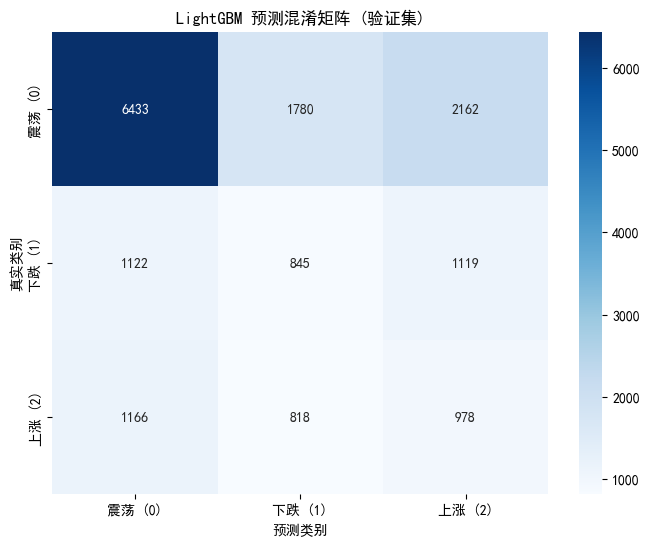

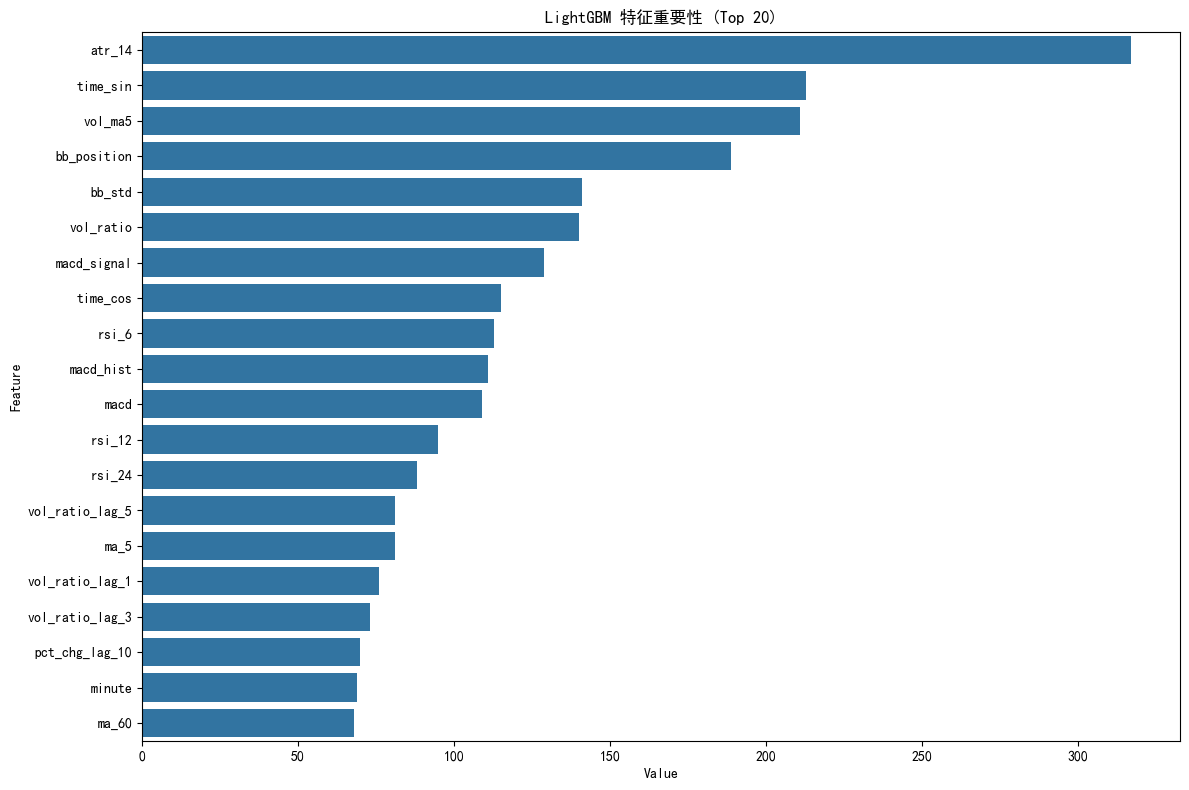

In [45]:
# ==========================================
# 5. 模型评估
# ==========================================
print("\n" + "="*50)
print("验证集评估报告")
print("="*50)

# 预测
y_pred = model.predict(X_val)

# 打印分类报告
# 注意：之前的 label 映射是 0:震荡, 1:跌, 2:涨
target_names = ['震荡 (0)', '下跌 (1)', '上涨 (2)']
print(classification_report(y_val, y_pred, target_names=target_names))

# 绘制混淆矩阵
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('LightGBM 预测混淆矩阵 (验证集)')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.show()

# ==========================================
# 6. 特征重要性分析
# ==========================================
feature_imp = pd.DataFrame({
    'Value': model.feature_importances_,
    'Feature': feature_cols
})

# 取前 20 个最重要的特征
plt.figure(figsize=(12, 8))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(20))
plt.title('LightGBM 特征重要性 (Top 20)')
plt.tight_layout()
plt.show()

# ==========================================
# 7. (可选) 保存模型
# ==========================================
# model.booster_.save_model('lgbm_model_fin.txt')
# print("模型已保存为 lgbm_model_fin.txt")

In [52]:
import optuna
import lightgbm as lgb
from sklearn.metrics import f1_score

def objective(trial):
    # 定义搜索空间
    param = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'class_weight': 'balanced',
        
        # 让 Optuna 建议参数
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0)
    }
    
    # 训练模型
    model = lgb.LGBMClassifier(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    # 返回优化的目标（例如 f1_weighted）
    return f1_score(y_val, preds, average='weighted')

# 创建学习任务
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # 尝试50次

print("最佳参数:", study.best_params)

[I 2026-01-22 15:43:43,530] A new study created in memory with name: no-name-ea97b249-b019-4a2f-be20-a2fe6015ff9c
[I 2026-01-22 15:43:45,382] Trial 0 finished with value: 0.511714109007819 and parameters: {'learning_rate': 0.09906329661586108, 'n_estimators': 588, 'max_depth': 7, 'num_leaves': 21, 'reg_alpha': 1.4073095794566032e-06, 'reg_lambda': 5.177694479701022, 'colsample_bytree': 0.40251069126463623, 'subsample': 0.5339818745720672}. Best is trial 0 with value: 0.511714109007819.
[I 2026-01-22 15:43:48,247] Trial 1 finished with value: 0.526936306510899 and parameters: {'learning_rate': 0.17302151661182483, 'n_estimators': 496, 'max_depth': 6, 'num_leaves': 96, 'reg_alpha': 1.6049813925349082e-08, 'reg_lambda': 4.846938953771682e-05, 'colsample_bytree': 0.9369580142136712, 'subsample': 0.9680936461225002}. Best is trial 1 with value: 0.526936306510899.
[I 2026-01-22 15:43:50,433] Trial 2 finished with value: 0.5067243824048827 and parameters: {'learning_rate': 0.03277168318943641

最佳参数: {'learning_rate': 0.1882120880792161, 'n_estimators': 697, 'max_depth': 9, 'num_leaves': 72, 'reg_alpha': 0.0064097012808077645, 'reg_lambda': 0.6973720183221711, 'colsample_bytree': 0.8938648513163806, 'subsample': 0.6990921242415814}



使用最佳参数在完整训练集上重新训练，并在保留验证集(X_val)上评估...

最终验证集分类报告:
              precision    recall  f1-score   support

      震荡 (0)       0.68      0.90      0.78     10375
      下跌 (1)       0.31      0.12      0.17      3086
      上涨 (2)       0.30      0.14      0.19      2962

    accuracy                           0.62     16423
   macro avg       0.43      0.39      0.38     16423
weighted avg       0.54      0.62      0.56     16423



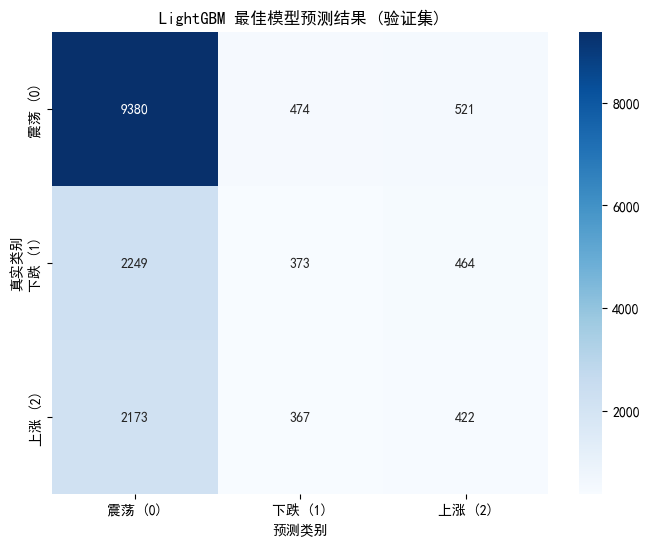

In [55]:
# 4. 使用最佳参数重新训练并评估 (在独立验证集 X_val 上)
# ==========================================
print("\n使用最佳参数在完整训练集上重新训练，并在保留验证集(X_val)上评估...")

best_model = lgb.LGBMClassifier(**study.best_params, objective='multiclass', num_class=3, n_jobs=-1)
best_model.fit(X_train, y_train)

y_pred_val = best_model.predict(X_val)

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

target_names = ['震荡 (0)', '下跌 (1)', '上涨 (2)']
print("\n最终验证集分类报告:")
print(classification_report(y_val, y_pred_val, target_names=target_names))

# 绘制混淆矩阵
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('LightGBM 最佳模型预测结果 (验证集)')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.show()

In [51]:
import optuna
import lightgbm as lgb
from sklearn.metrics import f1_score

def objective(trial):
    # 定义搜索空间
    param = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        'class_weight': 'balanced',
        
        # 让 Optuna 建议参数
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0)
    }
    
    # 训练模型
    model = lgb.LGBMClassifier(**param)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    
    # 返回优化的目标（例如 f1_weighted）
    return f1_score(y_val, preds, average='weighted')

# 创建学习任务
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # 尝试50次

print("最佳参数:", study.best_params)

[I 2026-01-22 15:43:00,753] A new study created in memory with name: no-name-3386f13c-3244-4623-a0e2-41a9a45c0d52
[I 2026-01-22 15:43:03,931] Trial 0 finished with value: 0.5036432425153657 and parameters: {'learning_rate': 0.09418865945929909, 'n_estimators': 622, 'max_depth': 3, 'num_leaves': 23, 'reg_alpha': 5.325474714295413e-06, 'reg_lambda': 2.4122414261569388e-06, 'colsample_bytree': 0.4109120115379457, 'subsample': 0.9619491603121191}. Best is trial 0 with value: 0.5036432425153657.
[I 2026-01-22 15:43:07,636] Trial 1 finished with value: 0.5152942823050156 and parameters: {'learning_rate': 0.18159825067791086, 'n_estimators': 869, 'max_depth': 5, 'num_leaves': 89, 'reg_alpha': 8.901764528199295e-07, 'reg_lambda': 0.00023589576588511706, 'colsample_bytree': 0.589908778599889, 'subsample': 0.5511422809253785}. Best is trial 1 with value: 0.5152942823050156.
[I 2026-01-22 15:43:10,633] Trial 2 finished with value: 0.5200571369991708 and parameters: {'learning_rate': 0.01054256817

KeyboardInterrupt: 

In [32]:
# 选择最重要的特征（约15个）
important_feature_cols = [
    'ma_5', 'ma_20', 'ma_60', 
    'price_ma5_ratio', 'price_ma20_ratio', 'price_ma60_ratio',
    'ma5_ma20_ratio',
    'momentum_5', 'momentum_10',
    'volatility_20',
    'position_in_20day_range',
    'price_change_1', 'price_change_5',
    'day_of_week',
    'close_lag1'
]

print(f"使用的特征数量: {len(important_feature_cols)}")
print("使用的特征列表:")
for i, feat in enumerate(important_feature_cols, 1):
    print(f"{i}. {feat}")

使用的特征数量: 15
使用的特征列表:
1. ma_5
2. ma_20
3. ma_60
4. price_ma5_ratio
5. price_ma20_ratio
6. price_ma60_ratio
7. ma5_ma20_ratio
8. momentum_5
9. momentum_10
10. volatility_20
11. position_in_20day_range
12. price_change_1
13. price_change_5
14. day_of_week
15. close_lag1
